#ARMA

ARMA (p, q) combines:

AR(p): AutoRegressive part – uses past values.

MA(q): Moving Average part – uses past forecast errors.

#🔢 General ARMA Equation:

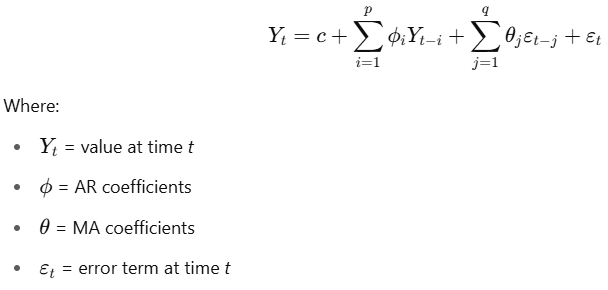

#⚙️ Prerequisites

In [1]:
pip install statsmodels matplotlib pandas


#📘 Step-by-Step Python Tutorial for ARMA

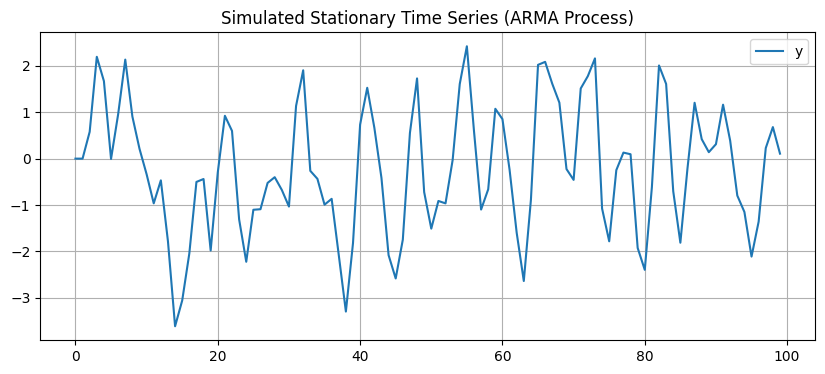

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Generate synthetic stationary time series data
np.random.seed(42)
n = 100
e = np.random.normal(0, 1, n)
y = np.zeros(n)
for t in range(2, n):
    y[t] = 0.6 * y[t-1] - 0.3 * y[t-2] + e[t] + 0.5 * e[t-1]

# Create DataFrame
df = pd.DataFrame({'y': y})

# Plot the data
df.plot(title="Simulated Stationary Time Series (ARMA Process)", figsize=(10, 4))
plt.grid()
plt.show()


#🧪 Step 1: Stationarity Check (ADF Test)

#✅ What is the ADF Test?

ADF stands for Augmented Dickey-Fuller test.
It is a statistical test used to check if a time series is stationary or not.

> Stationary = A time series whose statistical properties (mean, variance) do not change over time.

#🔬 Why Stationarity Matters?

Most time series models (like ARMA, ARIMA) assume the series is stationary.
If it's not, the model may give unreliable results.

#🧪 ADF Test Hypotheses:

Null Hypothesis (H₀): The time series has a unit root → Non-stationary

Alternative Hypothesis (H₁): The time series is stationary

#📊 What is the p-value?

The p-value helps decide whether to reject the null hypothesis.

| p-value | Interpretation             | Decision                                 |
| ------- | -------------------------- | ---------------------------------------- |
| < 0.05  | Strong evidence against H₀ | ✅ **Reject H₀** → Stationary             |
| > 0.05  | Weak evidence against H₀   | ❌ **Fail to Reject H₀** → Non-stationary |


In [3]:
result = adfuller(df['y'])
print(f"ADF Statistic: {result[0]}")  #ADF Statistic: More negative = stronger evidence of stationarity.
print(f"p-value: {result[1]}")        #p-value: Probability of data being non-stationary (if H₀ is true).

# p-value < 0.05 implies stationarity


ADF Statistic: -4.739564201608811
p-value: 7.08718985392759e-05


#🔧 Step 2: Fit the ARMA Model

Note: In statsmodels, ARMA is included under ARIMA where d=0.

In [4]:
# Fit ARMA(p=2, q=1) as we generated
model = ARIMA(df['y'], order=(2, 0, 1))  # (p, d=0, q)
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -131.906
Date:                Fri, 18 Jul 2025   AIC                            273.812
Time:                        10:37:36   BIC                            286.838
Sample:                             0   HQIC                           279.084
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2308      0.175     -1.319      0.187      -0.574       0.112
ar.L1          0.5646      0.173      3.269      0.001       0.226       0.903
ar.L2         -0.3450      0.126     -2.735      0.0

#📈 Step 3: Plot Predictions

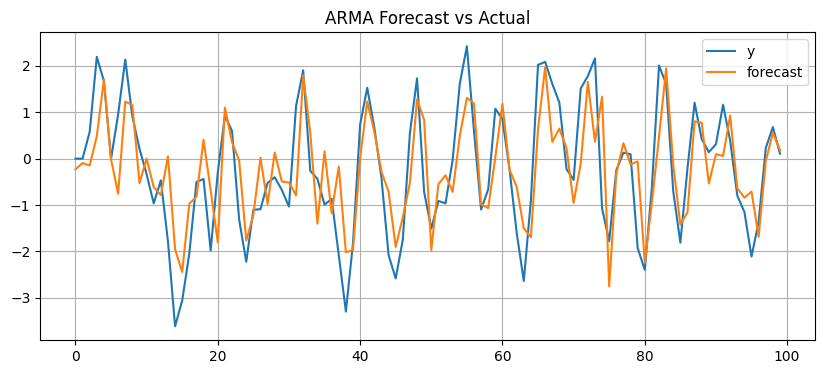

In [5]:
df['forecast'] = model_fit.predict()

df.plot(title="ARMA Forecast vs Actual", figsize=(10, 4))
plt.grid()
plt.show()


#✅ Interpretation

>ARIMA(order=(p,0,q)) is used for ARMA when data is already stationary.

>model_fit.summary() provides:

1.AR coefficients (ar.L1, ar.L2, etc.)

2.MA coefficients (ma.L1)

3.AIC/BIC for model selection

>predict() gives in-sample prediction; use forecast() for future.

#📎 When to Use ARMA

| Use Case       | Condition                                     |
| -------------- | --------------------------------------------- |
| ARMA           | Data is **stationary**                        |
| ARIMA          | Data is **non-stationary** (use differencing) |
| SARIMA/SARIMAX | Seasonality involved                          |
